In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        DATA_DIR / 'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [39]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from bisect import bisect_left

In [40]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [41]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [42]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [43]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [44]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [45]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [46]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [47]:
positive = pd.read_csv(DATA_DIR / 'simulated' / 'positive.csv').reset_index(drop=True)

In [48]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,-0.573381,0.247321,-0.850860,0.762083,0.339238,-0.637309,0.084158,0.069957,0.755836,0.107197,...,-1.789593,0.548035,1.564705,0.600867,0.310973,-0.036847,-1.546058,0.541649,-0.113102,-0.77693
1,0.623277,1.115454,-1.271686,-0.757640,-0.493047,0.400064,-1.513585,-0.534710,-1.358238,-0.648840,...,1.691098,-1.086276,0.314383,-0.801614,-0.960581,0.769900,-2.550973,0.817177,0.441524,1.39941


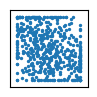

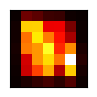

In [61]:
# n --> 0-19 = linear; 20-39 = parabolic; 40-59 = sine; 60-79 = circle; 80-99 = L
n=90
centers = np.linspace(-2, 2, 7)
eps_std = 1
x = positive[2*n:2*n+1].to_numpy()[0] + eps(np.size(x), eps_std)
y = positive[2*n+1:2*n+2].to_numpy()[0] + eps(np.size(x), eps_std)
# x = out[0:1].to_numpy()[0]
# y = out[1:2].to_numpy()[0]
x[x>max(centers)] = max(centers)
x[x<min(centers)] = min(centers)
y[y>max(centers)] = max(centers)
y[y<min(centers)] = min(centers)
x /= np.std(x)
y /= np.std(y)

plt.figure(figsize=(1, 1))
plt.scatter(x, y, s=2)
plt.xlim(min(centers), max(centers))
plt.ylim(min(centers), max(centers))
plt.xticks([])
plt.yticks([])
plt.show()

dmap = densitymap(x, y, centers, centers, sigma = 0.1)[::-1]
# show heatmap
plt.figure(figsize=(1, 1))
plt.imshow(dmap, cmap='hot', interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.show()

In [69]:
eps_std = 1
df = pd.DataFrame()
for n in range(100):
    centers = np.linspace(-2, 2, 7)
    x = positive[2*n:2*n+1].to_numpy()[0] + eps(np.size(x), eps_std)
    y = positive[2*n+1:2*n+2].to_numpy()[0] + eps(np.size(x), eps_std)
    x[x>max(centers)] = max(centers)
    x[x<min(centers)] = min(centers)
    y[y>max(centers)] = max(centers)
    y[y<min(centers)] = min(centers)
    x /= np.std(x)
    y /= np.std(y)
    
    dmap = densitymap(x, y, centers, centers, sigma = 0.1).flatten()
    df = pd.concat([df, pd.DataFrame([dmap])], ignore_index=True)

df += 1/len(df.columns)
df = df.map(np.log)
df.to_csv(DATA_DIR / 'simulated' / 'positive_heatmap.csv', index=False)


df = pd.DataFrame()
for _ in range(200):
    for n in range(100):
        centers = np.linspace(-2, 2, 7)
        x = positive[2*n:2*n+1].to_numpy()[0] + eps(np.size(x), eps_std)
        y = positive[2*n+1:2*n+2].to_numpy()[0] + eps(np.size(x), eps_std)
        np.random.shuffle(y)
        x[x>max(centers)] = max(centers)
        x[x<min(centers)] = min(centers)
        y[y>max(centers)] = max(centers)
        y[y<min(centers)] = min(centers)
        x /= np.std(x)
        y /= np.std(y)
        
        dmap = densitymap(x, y, centers, centers, sigma = 0.1).flatten()
        df = pd.concat([df, pd.DataFrame([dmap])], ignore_index=True)

df += 1/len(df.columns)
df = df.map(np.log)
df.to_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv', index=False)

In [70]:
from scipy.stats import pearsonr

# ---------- POSITIVE ----------
df = pd.DataFrame()

for n in range(100):
    
    x = positive.iloc[2*n].to_numpy()
    y = positive.iloc[2*n+1].to_numpy()
    
    x = x + eps(len(x), eps_std)
    y = y + eps(len(y), eps_std)
    
    # standardize
    x = x / np.std(x)
    y = y / np.std(y)
    
    r, _ = pearsonr(x, y)
    
    df = pd.concat([df, pd.DataFrame([[r]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'positive_pearson.csv'),
    index=False
)


# ---------- NEGATIVE ----------
df = pd.DataFrame()

for _ in range(200):
    for n in range(100):
        eps_std = 0.5
        
        x = positive.iloc[2*n].to_numpy()
        y = positive.iloc[2*n+1].to_numpy()
        
        x = x + eps(len(x), eps_std)
        y = y + eps(len(y), eps_std)
        
        np.random.shuffle(y)
        
        x = x / np.std(x)
        y = y / np.std(y)
        
        r, _ = pearsonr(x, y)
        
        df = pd.concat([df, pd.DataFrame([[r]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'negative_pearson.csv'),
    index=False
)

In [71]:
from scipy.stats import spearmanr

# ---------- POSITIVE ----------
df = pd.DataFrame()

for n in range(100):
    
    x = positive.iloc[2*n].to_numpy()
    y = positive.iloc[2*n+1].to_numpy()
    
    x = x + eps(len(x), eps_std)
    y = y + eps(len(y), eps_std)
    
    x = x / np.std(x)
    y = y / np.std(y)
    
    r, _ = spearmanr(x, y)
    
    df = pd.concat([df, pd.DataFrame([[r]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'positive_spearman.csv'),
    index=False
)


# ---------- NEGATIVE ----------
df = pd.DataFrame()

for _ in range(200):
    for n in range(100):
        eps_std = 0.5
        
        x = positive.iloc[2*n].to_numpy()
        y = positive.iloc[2*n+1].to_numpy()
        
        x = x + eps(len(x), eps_std)
        y = y + eps(len(y), eps_std)
        
        np.random.shuffle(y)
        
        x = x / np.std(x)
        y = y / np.std(y)
        
        r, _ = spearmanr(x, y)
        
        df = pd.concat([df, pd.DataFrame([[r]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'negative_spearman.csv'),
    index=False
)

In [72]:
from sklearn.feature_selection import mutual_info_regression
def compute_mi(x, y):
    # sklearn expects X to be 2D
    return mutual_info_regression(
        x.reshape(-1, 1),
        y,
        discrete_features=False
    )[0]

# ---------- POSITIVE ----------
df = pd.DataFrame()

for n in range(100):
    
    x = positive.iloc[2*n].to_numpy()
    y = positive.iloc[2*n+1].to_numpy()
    
    x = x + eps(len(x), eps_std)
    y = y + eps(len(y), eps_std)
    
    x = x / np.std(x)
    y = y / np.std(y)
    
    mi = compute_mi(x, y)
    
    df = pd.concat([df, pd.DataFrame([[mi]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'positive_mi.csv'),
    index=False
)


# ---------- NEGATIVE ----------
df = pd.DataFrame()

for _ in range(200):
    for n in range(100):
        
        eps_std = 0.5
        
        x = positive.iloc[2*n].to_numpy()
        y = positive.iloc[2*n+1].to_numpy()
        
        x = x + eps(len(x), eps_std)
        y = y + eps(len(y), eps_std)
        
        np.random.shuffle(y)
        
        x = x / np.std(x)
        y = y / np.std(y)
        
        mi = compute_mi(x, y)
        
        df = pd.concat([df, pd.DataFrame([[mi]])], ignore_index=True)

df.to_csv(DATA_DIR / 'simulated' / 'negative_mi.csv'),
    index=False
)

In [73]:
# A computation function
def bicor(x, y, c=9.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove missing values
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan

    # Median and MAD
    x_med = np.median(x)
    y_med = np.median(y)

    x_mad = np.median(np.abs(x - x_med))
    y_mad = np.median(np.abs(y - y_med))

    if x_mad == 0 or y_mad == 0:
        return np.nan

    # Standardized distances
    ux = (x - x_med) / (c * x_mad)
    uy = (y - y_med) / (c * y_mad)

    # Weights
    wx = (1 - ux**2)**2
    wy = (1 - uy**2)**2
    wx[np.abs(ux) >= 1] = 0
    wy[np.abs(uy) >= 1] = 0

    # Weighted values
    xw = (x - x_med) * wx
    yw = (y - y_med) * wy

    numerator = np.sum(xw * yw)
    denominator = np.sqrt(np.sum(xw**2) * np.sum(yw**2))

    return numerator / denominator if denominator != 0 else np.nan



In [74]:
# ---------- POSITIVE ----------
bicor_list = []

for n in range(100):
    
    x = positive.iloc[2*n].to_numpy()
    y = positive.iloc[2*n+1].to_numpy()
    
    x = x + eps(len(x), eps_std)
    y = y + eps(len(y), eps_std)
    
    # Optional standardization
    x = x / np.std(x)
    y = y / np.std(y)
    
    bicor_val = bicor(x, y, c=9.0)
    
    bicor_list.append(bicor_val)

df_positive = pd.DataFrame(bicor_list, columns=['BiCor'])
df_positive.to_csv(DATA_DIR / 'simulated' / 'positive_bicor.csv'),
    index=False
)

# ---------- NEGATIVE ----------
bicor_list = []

for _ in range(200):
    for n in range(100):
        
        eps_std = 0.5
        
        x = positive.iloc[2*n].to_numpy()
        y = positive.iloc[2*n+1].to_numpy()
        
        x = x + eps(len(x), eps_std)
        y = y + eps(len(y), eps_std)
        
        # Shuffle y to break correlation
        np.random.shuffle(y)
        
        # Optional standardization
        x = x / np.std(x)
        y = y / np.std(y)
        
        bicor_val = bicor(x, y, c=9.0)
        
        bicor_list.append(bicor_val)

df_negative = pd.DataFrame(bicor_list, columns=['BiCor'])
df_negative.to_csv(DATA_DIR / 'simulated' / 'negative_bicor.csv'),
    index=False
)

In [16]:
df.to_csv(DATA_DIR / 'simulated' / 'negative_heatmap.csv', index=False)

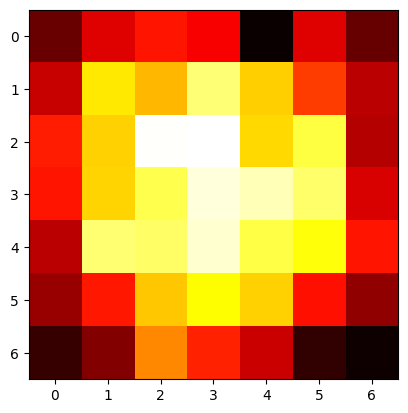

In [32]:
plt.imshow(df.iloc[100, :].to_numpy().reshape(7,7), cmap='hot', interpolation='nearest')
plt.show()